In [1]:
import joblib, numpy as np, pandas as pd
from sklearn.metrics import classification_report, f1_score

TYPE_MODEL = "type-tfidf-svm"        # best baseline from MLflow (no repo token)

df = pd.read_parquet("../data/processed/issues_clean.parquet")
vec, clf = joblib.load(f"../models/{TYPE_MODEL}.joblib")

typed = df.dropna(subset=["issue_type"])
test = typed[typed["split"] == "test"].copy()
test["pred"] = clf.predict(vec.transform(test["text_clean"]))
print(len(test), "test issues")
print(classification_report(test["issue_type"], test["pred"], zero_division=0))

2482 test issues
              precision    recall  f1-score   support

         bug       0.97      0.99      0.98      1645
        docs       0.98      0.89      0.93       361
     feature       0.94      0.94      0.94       466
    question       0.75      0.30      0.43        10

    accuracy                           0.96      2482
   macro avg       0.91      0.78      0.82      2482
weighted avg       0.96      0.96      0.96      2482



##  Which classes are confused, and where are the errors?

In [2]:
print("rows = true class, columns = predicted (counts)")
print(pd.crosstab(test["issue_type"], test["pred"]))
print("\nrows = true class (share of each true class)")
print(pd.crosstab(test["issue_type"], test["pred"], normalize="index").round(2))

test["wrong"] = test["pred"] != test["issue_type"]
print("\nerror rate per repo:")
print(test.groupby("repo")["wrong"].agg(["mean", "size"]).round(3))
print("\nmacro-F1 per repo:")
print(test.groupby("repo").apply(lambda g: f1_score(g["issue_type"], g["pred"], average="macro", zero_division=0)).round(3))

rows = true class, columns = predicted (counts)
pred         bug  docs  feature  question
issue_type                               
bug         1622     6       17         0
docs          27   322       11         1
feature       24     2      440         0
question       7     0        0         3

rows = true class (share of each true class)
pred         bug  docs  feature  question
issue_type                               
bug         0.99  0.00     0.01       0.0
docs        0.07  0.89     0.03       0.0
feature     0.05  0.00     0.94       0.0
question    0.70  0.00     0.00       0.3

error rate per repo:
                            mean  size
repo                                  
huggingface/transformers   0.004   733
microsoft/vscode           0.136   118
pandas-dev/pandas          0.037   891
scikit-learn/scikit-learn  0.058   740

macro-F1 per repo:
repo
huggingface/transformers     0.663
microsoft/vscode             0.532
pandas-dev/pandas            0.833
scikit-learn/sci

##  Does the model lean on title prefixes like `BUG:` or `ENH:`?

In [3]:
PREFIX = r"^\s*\[?(?:BUG|ENH|DOC|DOCS|PERF|FEAT|FEATURE|REGR|API|BLD|CLN|TST|TYP|QST)\]?\s*[:\-\]]"
test["has_prefix"] = test["title"].str.contains(PREFIX, case=False, regex=True)

print("share of test titles with a prefix, per repo:")
print(test.groupby("repo")["has_prefix"].mean().round(2))
print("\naccuracy with / without prefix:")
print((~test["wrong"]).groupby(test["has_prefix"]).agg(["mean", "size"]).round(3))

no_pre = test[~test["has_prefix"]]
print("\nmacro-F1 on titles WITHOUT a prefix:",
      round(f1_score(no_pre["issue_type"], no_pre["pred"], average="macro", zero_division=0), 3))

share of test titles with a prefix, per repo:
repo
huggingface/transformers     0.08
microsoft/vscode             0.01
pandas-dev/pandas            0.96
scikit-learn/scikit-learn    0.10
Name: has_prefix, dtype: float64

accuracy with / without prefix:
             mean  size
has_prefix             
False       0.958  1492
True        0.967   990

macro-F1 on titles WITHOUT a prefix: 0.872


##  What words does the model use? (top features per class)

In [4]:
names = np.array(vec.get_feature_names_out())
for i, cls in enumerate(clf.classes_):
    top = np.argsort(clf.coef_[i])[-12:][::-1]
    print(f"{cls:9s}", ", ".join(names[top]))

bug       bug, codeblock, reproduce, with, self, to reproduce, fails, expected, behavior, reproduce codeblock, system, actual
docs      doc, documentation, docs, the documentation, document, docstring, url, the docs, user guide, linked, linked to, section
feature   enh, feature, feature request, request, support, add, motivation, your contribution, contribution, your, allow, currently
question  data, how can, how, column, question, qst, pipeline, stackoverflow, my, versions installed, want, feather xlsxwriter


## Read the mistakes (are they model errors or questionable labels?)

In [5]:
wrong = test[test["wrong"]]
for _, r in wrong.sample(min(15, len(wrong)), random_state=1).iterrows():
    print(f"[{r['repo']}] true={r['issue_type']}  pred={r['pred']}  labels={list(r['labels'])}")
    print("   ", r["title"][:110])

[pandas-dev/pandas] true=question  pred=bug  labels=['Missing-data', 'Usage Question']
    BUG: 1-element pd.NA boolean arrays are all() but not any()
[pandas-dev/pandas] true=feature  pred=bug  labels=['Enhancement', 'Needs Discussion', 'expressions', 'cut']
    ENH: Support expressions in `pd.qcut`
[pandas-dev/pandas] true=bug  pred=feature  labels=['Bug', 'Needs Discussion', 'Copy / view semantics', 'Closing Candidate']
    ENH/API: Architectural Audit - Are other inplace=True methods bypassing CoW reference tracking?
[scikit-learn/scikit-learn] true=docs  pred=bug  labels=['Documentation', 'Build / CI']
    issue in building from source with Windows64 Python 3.12.7
[scikit-learn/scikit-learn] true=bug  pred=feature  labels=['Bug', 'API', 'module:metrics']
    We don't support `func(estimator, X, y, ...)` across the board as a scorer
[pandas-dev/pandas] true=docs  pred=bug  labels=['Docs', 'Typing']
    BUG: DataFrame.eq() incorrectly rejects scalar strings in type annotations
[scik

##  Tags: per-tag scores and per-tag thresholds tuned on validation

In [6]:
TAG_MODEL = "tags-tfidf-lr"
tvec, tclf, mlb = joblib.load(f"../models/{TAG_MODEL}.joblib")
TAGS = list(mlb.classes_)

pool = df[df["labels"].apply(len) > 0]
def scores_and_truth(split):
    d = pool[pool["split"] == split]
    X = tvec.transform(d["text_clean"])
    return tclf.decision_function(X), mlb.transform([list(t) for t in d["tags"]])

S_val, Y_val = scores_and_truth("val")
S_test, Y_test = scores_and_truth("test")

# default threshold (0) vs threshold chosen per tag on validation
grid = np.linspace(-2.0, 2.0, 81)
best = {}
for j, tag in enumerate(TAGS):
    if Y_val[:, j].sum() == 0:
        best[tag] = 0.0
        continue
    f1s = [f1_score(Y_val[:, j], S_val[:, j] > t, zero_division=0) for t in grid]
    best[tag] = float(grid[int(np.argmax(f1s))])

default_pred = S_test > 0
tuned_pred = S_test > np.array([best[t] for t in TAGS])

rows = []
for j, tag in enumerate(TAGS):
    rows.append({"tag": tag, "test_support": int(Y_test[:, j].sum()), "threshold": round(best[tag], 2),
                 "F1 default": round(f1_score(Y_test[:, j], default_pred[:, j], zero_division=0), 3),
                 "F1 tuned": round(f1_score(Y_test[:, j], tuned_pred[:, j], zero_division=0), 3)})
print(pd.DataFrame(rows).to_string(index=False))
print("\nmicro-F1  default:", round(f1_score(Y_test, default_pred, average="micro", zero_division=0), 3),
      " tuned:", round(f1_score(Y_test, tuned_pred, average="micro", zero_division=0), 3))
print("macro-F1  default:", round(f1_score(Y_test, default_pred, average="macro", zero_division=0), 3),
      " tuned:", round(f1_score(Y_test, tuned_pred, average="macro", zero_division=0), 3))

             tag  test_support  threshold  F1 default  F1 tuned
             api            61      -0.30       0.333     0.310
        build_ci           101       0.75       0.441     0.377
needs_discussion           261      -0.75       0.354     0.385
      needs_info            94      -0.65       0.279     0.239
     performance            74       0.45       0.713     0.672
      regression            57       1.20       0.245     0.337
    spam_invalid            89       1.20       0.643     0.654

micro-F1  default: 0.4  tuned: 0.393
macro-F1  default: 0.43  tuned: 0.425


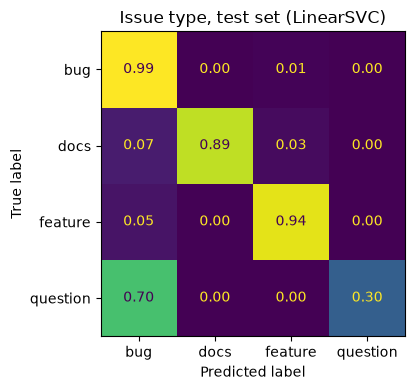

In [7]:
   import matplotlib.pyplot as plt
   from sklearn.metrics import ConfusionMatrixDisplay
   fig, ax = plt.subplots(figsize=(5, 4))
   ConfusionMatrixDisplay.from_predictions(test["issue_type"], test["pred"], normalize="true", ax=ax, values_format=".2f", colorbar=False)
   ax.set_title("Issue type, test set (LinearSVC)"); fig.tight_layout(); fig.savefig("../docs/confusion_matrix_type.png", dpi=150)